In [ ]:
import os

for root, dirs, files in os.walk(r'C:\Users\priya\Downloads'):
    for file in files:
        if 'imdb' in file.lower() and file.lower().endswith('.csv'):
            print(os.path.join(root, file))

C:\Users\priya\Downloads\archive (4)\IMDB Dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv(r'C:\Users\priya\Downloads\archive (4)\IMDB Dataset.csv')
print(df.shape)
print(df['sentiment'].value_counts())
df.head()
%pip install nltk
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
%pip install scikit-learn

def clean_text(text):
    text = text.lower()                                  # lowercase
    text = re.sub(r'<.*?>', ' ', text)                   # remove HTML tags like <br />
    text = re.sub(r'[^a-z\s]', '', text)                 # remove punctuation and numbers
    words = text.split()                                 # tokenise
    words = [w for w in words if w not in stop_words]    # remove stopwords
    words = [lemmatizer.lemmatize(w) for w in words]     # lemmatize
    return ' '.join(words)
print("BEFORE:", df['review'][1][:300])
print("\nAFTER:", clean_text(df['review'][1])[:300])
df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review', 'sentiment']].head()
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})   # convert labels to numbers

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training reviews:", X_train.shape[0])
print("Testing reviews:", X_test.shape[0])
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)   # learn vocabulary from training data only
X_test_tfidf = tfidf.transform(X_test)         # apply the same vocabulary to test data

print("TF-IDF shape (train):", X_train_tfidf.shape)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print("Both models trained!")


(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Note: you may need to restart the kernel to use updated packages.
BEFORE: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

AFTER: wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen got polari voice pat truly see seamless editing guided reference williams diary entry well worth watching terrificl



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Training reviews: 40000
Testing reviews: 10000
TF-IDF shape (train): (40000, 5000)
Both models trained!



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
===== Naive Bayes =====
Accuracy : 0.8531
Precision: 0.8488
Recall   : 0.8592
F1-score : 0.854


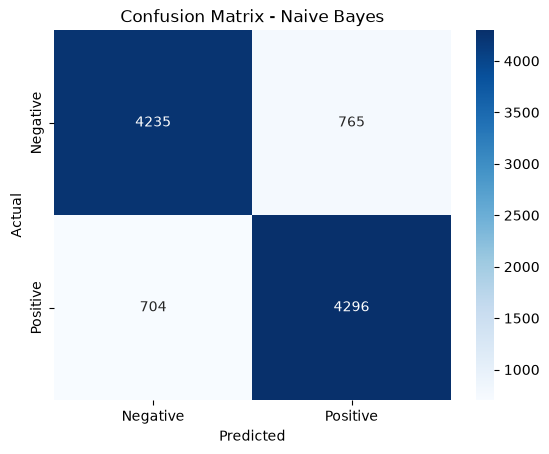

In [ ]:
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, name):
    y_pred = model.predict(X_test_tfidf)

    print(f"===== {name} =====")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1-score :", round(f1_score(y_test, y_pred), 4))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return y_pred
nb_pred = evaluate_model(nb_model, "Naive Bayes")

===== Logistic Regression =====
Accuracy : 0.8883
Precision: 0.8811
Recall   : 0.8978
F1-score : 0.8894


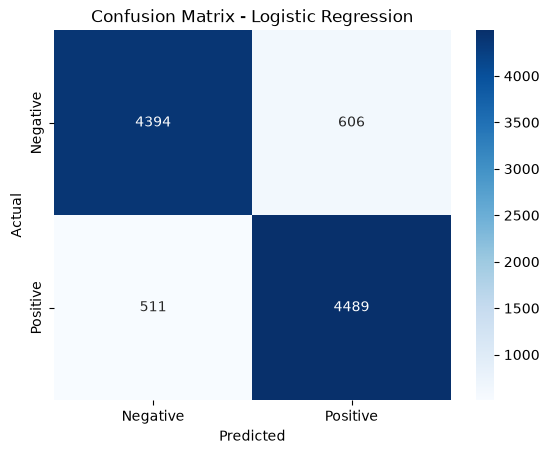

In [ ]:
lr_pred = evaluate_model(lr_model, "Logistic Regression")

Note: you may need to restart the kernel to use updated packages.
Naive Bayes accuracy       : 0.8531
Logistic Regression accuracy: 0.8883



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\priya\AppData\Local\Temp\ipykernel_21392\319007238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


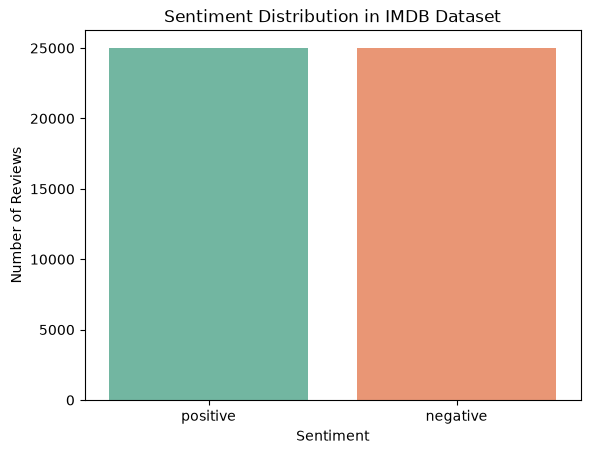

In [ ]:
%pip install wordcloud
print("Naive Bayes accuracy       :", round(accuracy_score(y_test, nb_pred), 4))
print("Logistic Regression accuracy:", round(accuracy_score(y_test, lr_pred), 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title("Sentiment Distribution in IMDB Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
results = pd.DataFrame({
    'review': df.loc[X_test.index, 'review'],
    'actual': y_test,
    'predicted': lr_pred
})

errors = results[results['actual'] != results['predicted']]
print("Total misclassified:", len(errors))

label_name = {1: 'positive', 0: 'negative'}
for _, row in errors.sample(5, random_state=42).iterrows():
    print("\nActual:", label_name[row['actual']], "| Predicted:", label_name[row['predicted']])
    print(row['review'][:400])
    print("-" * 80)

Total misclassified: 1117

Actual: negative | Predicted: positive
This film is worth seeing since it is a classic in the sense of being the very first full length film released in the process of three demention. It was not very good in its acting or story plot, but can be a great movie quiz question from an historical standpoint. It should be seen in the 3 D process with polarized lenses.
--------------------------------------------------------------------------------

Actual: positive | Predicted: negative
Watching "Plots with a View" (called "Undertaking Betty" in the US), I got the feeling that there need to be more movies filmed in Wales. This one portrays a woman (Brenda Blethyn) in a small Welsh town trying to get away from her cheating husband. So, she and the funeral parlor manager (Alfred Molina) come up with a plan...but there are likely to be some glitches along the way.<br /><br />I would
--------------------------------------------------------------------------------

Actu

In [2]:
import os
print(os.getcwd())
import os
print(os.getcwd())
print(os.path.exists('sentiment_analysis.ipynb'))

c:\Users\priya\Downloads\New folder (4)
c:\Users\priya\Downloads\New folder (4)
False
